# NSE vs. Direct Integration

In [1]:
import pynucastro as pyna
import warnings
warnings.filterwarnings('ignore')

## NSE Compatibility
Previously, we have demonstrated the ability to compute a unique composition by solving the NSE equation given input, $(\rho, T, Y_e)$.
Now the question arises on whether the equilibrium mass abundance obtained from integrating the reaction network will match, up to machine precision, with what is predicted from the NSE equation.
To understand this, we need to revisit the assumptions made when deriving the NSE equation, i.e.

1. Assumed that only strong-mediated nuclear reactions take place such that the $Y_e$ remains unchanged, i.e.

$$
   \sum_i \frac{Z_i X_i}{A_i} - Y_e =0
$$
   
2. Assumed that the mass fraction of any species is characterized by Boltzmann gas, see {ref}`gas_model`, such that

$$
X_i = \frac{m_i}{\rho}G_i \left(\frac{m_i k_B T}{2\pi\hbar^2}\right)^{3/2} \exp{\left(\frac{\mu_i - m_i c^2 - \mu^C_i}{k_B T}\right)}
$$

3. Assumed that the chemical potential of any species in the network can be represented as a linear combination of chemical potential of any 2 species. The NSE condition specifically chooses to work in the basis of proton and neutron, but any two can work. See Appendix B in {cite:t}`skynet` for reference.

$$
\mu_i = Z_i \mu_p + N_i \mu_n
$$

To resolve the assumptions made above consider the following:

To address assumption #1, consider a reaction network that includes a set of weak reaction rates, such that the electron fraction, $Y_e$, evolves according to

$$
\dot{Y}_e = \sum_i Z_i \dot{Y}_i^{\mathrm{weak}}
$$

where $\dot{Y}_i^{\mathrm{weak}}$ is the rate of change of the molar fraction of the $i$-th species due to weak rates. If the timescale for strong reactions to reach equilibrium is much shorter than the timescale for weak reactions, then the composition can still be treated as being in equilibrium with respect to the strong rates. In this case, the equilibrium composition is still well-defined as long as the electron fraction, $Y_e$, is evolved over time based on the weak rate contributions.

To address assumption #2, the reaction network must be consistent with the same Boltzmann-gas form of the mass fractions described in Eq. 2. This requires that every strong reaction is paired with its inverse reaction. One of the two rates, either forward or reverse, must
then be derived from the other using detailed balance. This is implemented by using {py:obj}`DerivedRate <pynucastro.rates.derived_rate.DerivedRate>`, see {ref}`derived_rate`.

```{warning}
Rates that use `stoichiometry` are not compatible with NSE. This is because the rate equation with `stoichiometry` is different from
the rate equation assumed when deriving the `DerivedRate`.
```
To address assumption #3, the reaction network must be sufficiently connected so that the chemical potential of any species and be expressed in terms of the chemical potentials of only two species. Consider a network with $N$ number of species and $M$ number of strong reaction pairs, then the difference in the chemical potential between the reactants and products for the $i$-th reaction pair can be written as

$$ S_{ij} \mu_j = \delta_i $$

where $\mu_j$ is the chemical potential of the $j$-th species, $S$ is the stoichiometric matrix of shape $(M, N)$, and $S_{ij}$ is the stoichiometric coefficient of the $j$-th species participated in the $i$-th reaction pair, with opposite signs depending on whether it is a reactant or a product. System reaches global chemical equilibrium for $\mu_j = \mu^{\mathrm{eq}}_j$ such that $\delta_i = 0$ for all reaction pairs.
For the equilibrium state to be consistent with NSE, the dimension of $\mu^{\mathrm{eq}}$ must not be greater than the maximum independent equilibrium chemical potentials, $\mathrm{MAX\_DIM}$. In general, $\mathrm{MAX\_DIM} = 2$ as there are two possible NSE constraints.
If all species in the network have the same $Z/A$ ratio, such as the $\alpha$-chain network, the $Y_e$ constraint becomes redundant and $\mathrm{MAX\_DIM} \rightarrow 1$. The mathematical equivalent statement is to require

$$
 \mathrm{nullity}(S) \leq \mathrm{MAX\_DIM}
$$

```{tip}
In pynucastro, {py:obj}`RateCollection <pynucastro.networks.rate_collection.RateCollection>` provides a convenient method, {py:meth}`isNSECompatible <pynucastro.networks.rate_collection.RateCollection.isNSECompatible>`, that checks all the above assumptions and pre-determines whether a network will be compatible with NSE. 
```

To demonstrate, we will create the {py:obj}`PythonNetwork <pynucastro.networks.python_network.PythonNetwork>` needed for direct integration using the same set of nuclei as our previous example.

First we recreate our library, but we make sure that we use reverse rates calculated via detailed balance.
In pynucastro, this is the {py:obj}`DerivedRate <pynucastro.rates.derived_rate.DerivedRate>`.

In [2]:
rl = pyna.ReacLibLibrary()

all_nuclei = ["p", "he4",
              "c12", "n13",
              "o16", "f17",
              "ne20", "na23",
              "mg24", "al27", "si28",
              "p31", "s32", "cl35",
              "ar36", "k39", "ca40",
              "sc43", "ti44", "v47",
              "cr48", "mn51",
              "fe52","co55","ni56"]

lib = rl.linking_nuclei(all_nuclei)

Here we search through the existing ReacLib reverse rates and remove them. So that `Library` only contains forward rates.  We use the {py:meth}`backward <pynucastro.rates.library.Library.backward>` method for this.

In [3]:
reverse_rates = lib.backward().get_rates()
for r in reverse_rates:
    lib.remove_rate(r)

Now create the corresponding `DerivedRate` using the forward rate and add them to `Library`. 

In [4]:
for r in lib.get_rates():
    d = pyna.DerivedRate(source_rate=r, use_pf=True)
    lib.add_rate(d)

We can also use {py:obj}`ModifiedRate <pynucastro.rates.modified_rate.ModifiedRate>` where we modify the reactants and/or the products of a reaction rate but still use the original rate. This is compatible with NSE as long as a corresponding `DerivedRate` is added.

In [5]:
other_rates = [("c12(c12,n)mg23", "mg24"),
               ("o16(o16,n)s31", "s32"),
               ("o16(c12,n)si27", "si28")]
for r, mp in other_rates:
    _r = rl.get_rate_by_name(r)
    forward_rate = pyna.ModifiedRate(_r, new_products=[mp])
    derived_rate = pyna.DerivedRate(source_rate=forward_rate, use_pf=True)
    lib.add_rates([forward_rate, derived_rate])

The {py:obj}`TemperatureTabularRate <pynucastro.rates.temperature_tabular_rate.TemperatureTabularRate>`, in which the strong reaction rate is tabulated, is also compatible with NSE as long as a corresponding `DerivedRate` is added. We will use {py:obj}`IliadisO16pgF17 <pynucastro.rates.alternate_rates.IliadisO16pgF17>`, a subclass of `TemperatureTabularRate` for `O16(p,g)F17` rate, as an example to demonstrate compatibility with NSE.

Let's remove the {py:obj}`ReacLibRate <pynucastro.rates.reaclib_rate.ReacLibRate>` version for `O16(p,g)F17` and its `DerivedRate` and add `IliadisO16pgF17` and its corresponding `DerivedRate`.

In [6]:
rates_to_remove = ["o16(p,g)f17", "f17(g,p)o16"]
for r in rates_to_remove:
    _r = lib.get_rate_by_name(r)
    lib.remove_rate(_r)

iliadis = pyna.rates.alternate_rates.IliadisO16pgF17()
iliadis_derived = pyna.DerivedRate(iliadis, use_pf=True)

lib.add_rate(iliadis)
lib.add_rate(iliadis_derived)

Now create the `PythonNetwork` using the modified `Library` object.

In [7]:
net = pyna.PythonNetwork(libraries=lib)

We can also do some approximations, such as the $(\alpha,p)(p,\gamma)$ approximation. This is fully compatible with NSE.

In [8]:
net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47", "mn51"])
net.remove_nuclei(["cl35", "k39", "sc43", "v47", "mn51"])
net.summary()

Network summary
---------------
  explicitly carried nuclei: 20
  approximated-out nuclei: 5
  inert nuclei (included in carried): 0

  total number of rates: 107

  rates explicitly connecting nuclei: 74
  hidden rates: 33

  reaclib rates: 46
  starlib rates: 0
  temperature tabular rates: 1
  weak tabular rates: 0
  approximate rates: 10
  derived rates: 47
  modified rates: 3
  custom rates: 0


Let's predict whether our network `net` will be compatible with NSE by using `isNSECompatible()`

```{tip}
Set `verbose=True` when creating the network to output additional information of the network property such as the rank of the stoichiometric matrix, $S$.
```

In [9]:
net.verbose = True
print(f"Is net compatible with NSE? {net.isNSECompatible()}")

NSE Compatibility Summary 
-------------------------
  Nullity: 2
  Rank: 18
  Max allowed dimension: 2
  Number of species: 20

Is net compatible with NSE? True


We see that in theory, this network will be compatible with NSE. Now let's verify it by integrating directly.

## Direct integration

In [10]:
import matplotlib.pyplot as plt
import numpy as np

Now we want to integrate. For convenience, let's use {py:meth}`integrate_network <pynucastro.networks.python_network.PythonNetwork.integrate_network>`
Since we will compare to NSE, we want to use the same screening that NSE uses -- {py:meth}`potekhin_1998 <pynucastro.screening.screen.potekhin_1998>`. This can be enabled via `screen_method="potekhin_1998`

In [11]:
sol = net.integrate_network(tmax=1.e-1, rho=1e7, T=6e9, initial_comp="uniform", 
                            screen_method="potekhin_1998", rtol=3.e-14, atol=3.e-14)

Let's plot the evolution to see how mass fraction evolve with time via {py:meth}`plot_evolution <pynucastro.networks.python_network.PythonNetwork.plot_evolution>`. Equilibrium is indicated by flat lines.

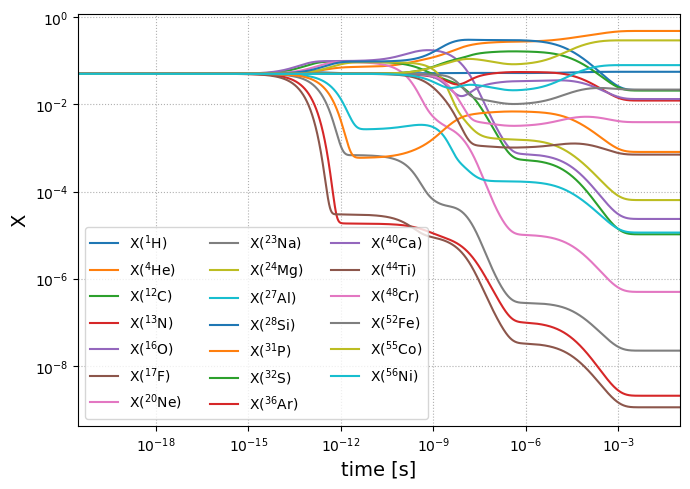

In [12]:
fig = net.plot_evolution(sol, size=(700, 500))

## Comparing with NSE calculation

We can create an {py:obj}`NSENetwork <pynucastro.networks.nse_network.NSENetwork>` by simply grabbing the rates from our current network and using them to construct the NSE network. From the `NSENetwork`, we can directly compute the NSE state, and make some plots to compare it to the integration results.

In [13]:
def NSE_comparison(mynet, sol, rho=1e7, T=6e9):

    # Create the NSENetwork
    nse_net = pyna.NSENetwork(rates=mynet.get_rates())

    # Compute electron fraction assuming uniform composition.
    # This is to avoid numerical error deviating from the initial electron fraction
    ye = sum(nuc.Z / nuc.A for i, nuc in enumerate(mynet.unique_nuclei)) / len(mynet.unique_nuclei)
    
    # Compute the NSE state
    nse_comp = nse_net.get_comp_nse(rho, T, ye, init_guess=(-3.5, -14.0), use_coulomb_corr=True)

    # Make plots to see comparison between the two results
    As = np.array([nuc.A for nuc in mynet.unique_nuclei])
    X_net = sol.y[:,-1]*As
    X_nse = np.array(list(nse_comp.X.values()))
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
    nuc_labels = [rf"${nuc.pretty}$" for nuc in mynet.unique_nuclei]
    
    # Abundance Histogram plot
    x = np.arange(len(mynet.unique_nuclei))
    width = 0.35
    
    ax1.bar(x - width/2.0, X_nse, width, label = 'NSE')
    ax1.bar(x + width/2.0, X_net, width, label = 'Integration')
    
    ax1.set_ylabel("Mass fractions", fontsize=14)
    ax1.set_yscale("log")
    ax1.set_ylim(ymax=1)
    ax1.legend(fontsize=14)

    # Error plot
    diff = np.abs(X_net - X_nse) 
    diff_rel = diff / X_net
    
    ax2.scatter(x, diff, label='Absolute Error', marker='o', color='r', s=40)
    ax2.scatter(x, diff_rel, label='Relative Error', marker ='x', color='b', s=40)
    
    ax2.set_xlabel("Nucleus", fontsize=14)
    ax2.set_ylabel("Error", fontsize=14)
    ax2.set_yscale("log")
    ax2.set_ylim(ymax=1.01)
    ax2.grid(ls=":")
    ax2.legend(fontsize=14)
    
    ax2.set_xticks(x, labels=nuc_labels, rotation=90, fontsize=14)
    fig.tight_layout()

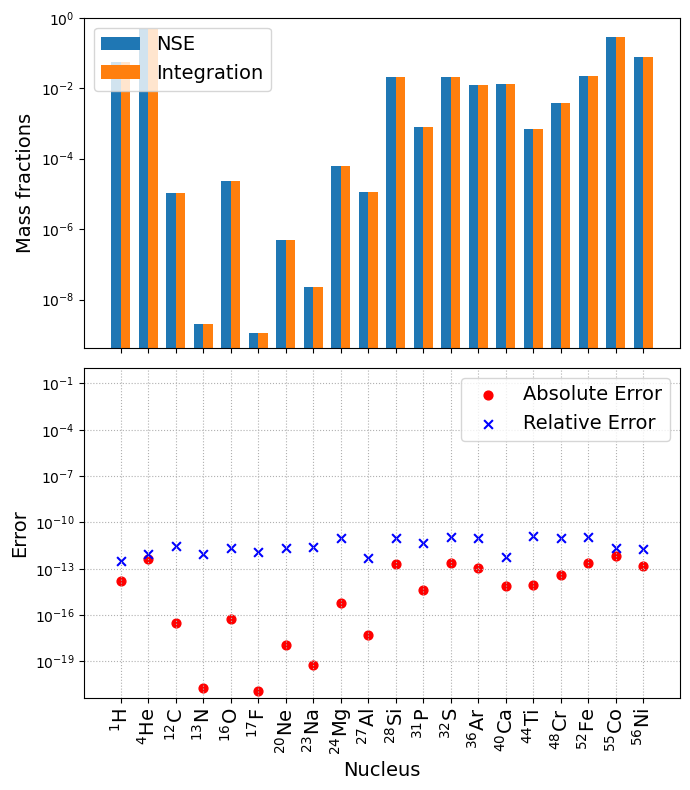

In [14]:
NSE_comparison(net, sol)

We see that the plot of absolute and relative difference shows that the mass fraction obtained from direct integration matches with NSE equations to machine precision just as `isNSECompatible()` predicted. The differences between the two are largely set by the tolerances of both the NSE solver and the ODE integrator.

## Visualizing equilibrium

At equilibrium, the forward and reverse rates linking nuclei should come into balance.  We can visualize this
graphically using the network {py:meth}`plot <pynucastro.networks.rate_collection.RateCollection.plot>` function,
and plotting the difference between the forward and reverse rates (`use_net_rate=True`).  We will also normalize
by the total activity of the rate (forward + reverse) by doing `normalize_net_rate=True`.

First we'll convert the final composition from the integration into a pynucastro {py:obj}`Composition <pynucastro.nucdata.composition.Composition>`, keeping in mind that the network evolved molar fractions ($Y = X / A$).

In [15]:
from pynucastro.screening import potekhin_1998 

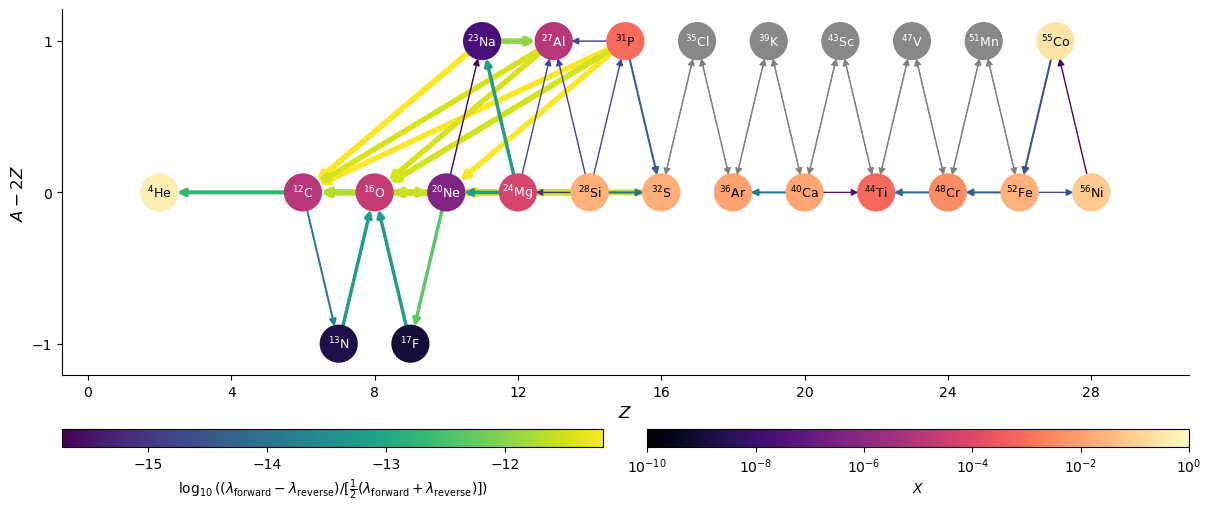

In [16]:
rho = 1e7
T = 6e9
comp = pyna.Composition(net.unique_nuclei)
comp.set_array(sol.y[:, -1] * np.array(list(comp.A.values())))

fig = net.plot(rho, T, comp,
               screen_func=potekhin_1998,
               rotated=True, size=(1200, 500),
               node_size=650, node_font_size="9",
               use_net_rate=True, normalize_net_rate=True,
               color_nodes_by_abundance=True,
               hide_xalpha=True)

Here we see that the normalized net rates are all < $10^{-12}$, so we are effectively seeing the integration tolerance, and are very close to machine precision.

## Examples of incompatibility

We previously demonstrated a potentially useful 19-nuclei network for Helium burning, where the network is intrinsically compatible with NSE. Now the question is what are some examples that are not compatible with NSE?

Let's consider expanding the network with more iron-group species by adding two rate pairs

$$
{}^{52}\mathrm{Fe} + \mathrm{n} \rightleftharpoons {}^{53}\mathrm{Fe}
$$

$$
 {}^{53}\mathrm{Fe} + \mathrm{n} \rightleftharpoons {}^{54}\mathrm{Fe}
$$

In [17]:
fe52n_fe53 = rl.get_rate_by_name("fe52(n,g)fe53")
fe53_fe52n = pyna.DerivedRate(source_rate=fe52n_fe53, use_pf=True)

fe53n_fe54 = rl.get_rate_by_name("fe53(n,g)fe54")
fe54_fe53n = pyna.DerivedRate(source_rate=fe53n_fe54, use_pf=True)

net.add_rates([fe52n_fe53, fe53_fe52n,
               fe53n_fe54, fe54_fe53n])

Check if it is still compatible with NSE via `isNSECompatible()`

In [18]:
print(f"Is net compatible with NSE? {net.isNSECompatible()}")

NSE Compatibility Summary 
-------------------------
  Nullity: 3
  Rank: 20
  Max allowed dimension: 2
  Number of species: 23

Is net compatible with NSE? False


Here we see that the nullity of the stoichiometric matrix exceeds the maximum allowed dimension, hence it is not compatible with NSE.
But let's verify it by integrating the network.

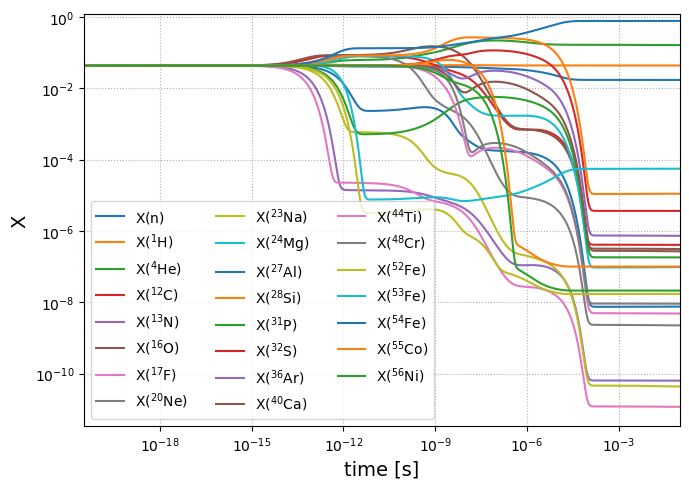

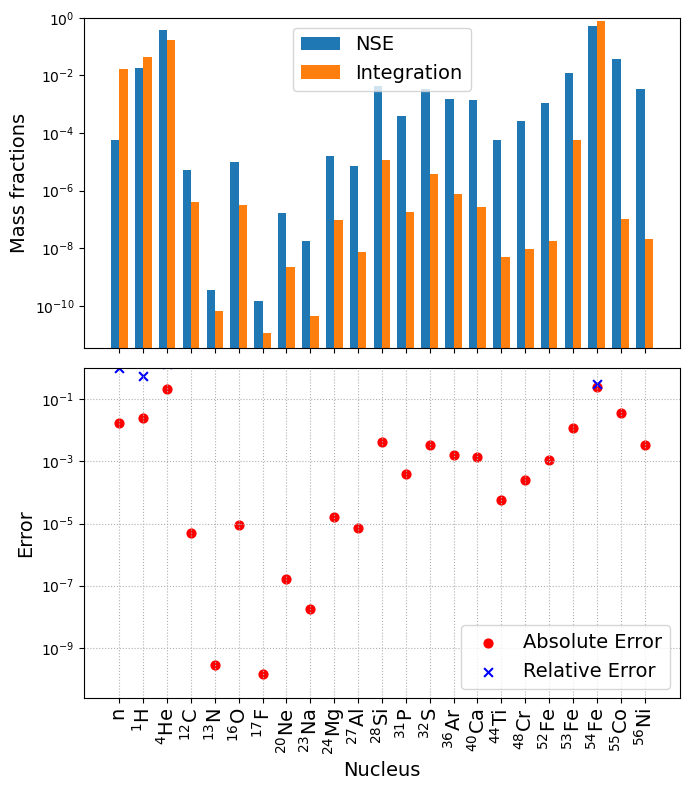

In [19]:
sol = net.integrate_network(tmax=1.e-1, rho=1e7, T=6e9, initial_comp="uniform", 
                            screen_method="potekhin_1998", rtol=3.e-14, atol=3.e-14)
fig = net.plot_evolution(sol, size=(700, 500))
NSE_comparison(net, sol)

We see that the mass abundance computed from NSE is indeed different from integrating the network to equilibrium,
suggesting the isotopes are not sufficiently connected. To resolve this issue, we need additional rates to provide connections
from the newly added ${}^{54}\mathrm{Fe}$ to ${}^{55}\mathrm{Co}$. Let's consider adding,

$$
{}^{54}\mathrm{Fe} + \mathrm{p} \rightleftharpoons {}^{55}\mathrm{Co}
$$

This rate completes the loop between ${}^{52}\mathrm{Fe}$, ${}^{53}\mathrm{Fe}$, ${}^{54}\mathrm{Fe}$, and ${}^{55}\mathrm{Co}$,
allowing for the exchange of ${}^{4}\mathrm{He}$ to 2 protons and 2 neutrons

In [20]:
fe54p_co55 = rl.get_rate_by_name("fe54(p,g)co55")
co55_fe54p = pyna.DerivedRate(source_rate=fe54p_co55, use_pf=True)

net.add_rates([fe54p_co55, co55_fe54p])

In [21]:
print(f"Is net compatible with NSE? {net.isNSECompatible()}")

NSE Compatibility Summary 
-------------------------
  Nullity: 2
  Rank: 21
  Max allowed dimension: 2
  Number of species: 23

Is net compatible with NSE? True


Now we see that the network is compatible with NSE as nullity and the maximum allowed dimension are now the same. 
But we can do better by approximating out ${}^{53}\mathrm{Fe}$ using the double neutron-capture approximation.

In [22]:
net.make_nn_g_approx(intermediate_nuclei=["fe53"])
net.remove_nuclei(["fe53"])
print(f"Is net compatible with NSE? {net.isNSECompatible()}")

approximating out Fe53
using approximate rate Fe52 + n + n ⟶ Fe54 + 𝛾
using approximate rate Fe54 ⟶ Fe52 + n + n
removing rate Fe52 + n ⟶ Fe53 + 𝛾
removing rate Fe53 + n ⟶ Fe54 + 𝛾
removing rate Fe54 ⟶ n + Fe53
removing rate Fe53 ⟶ n + Fe52
NSE Compatibility Summary 
-------------------------
  Nullity: 2
  Rank: 20
  Max allowed dimension: 2
  Number of species: 22

Is net compatible with NSE? True


We see that using the double neutron-capture approximation remains compatible with NSE.
It reduces both the rank of the stoichiometric matrix and the number of species by one, leaving nullity unchanged.
Let's verify its prediction by integrating the network.

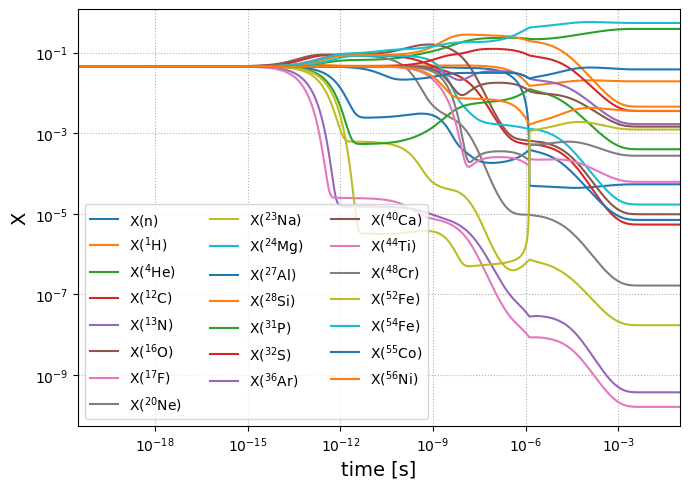

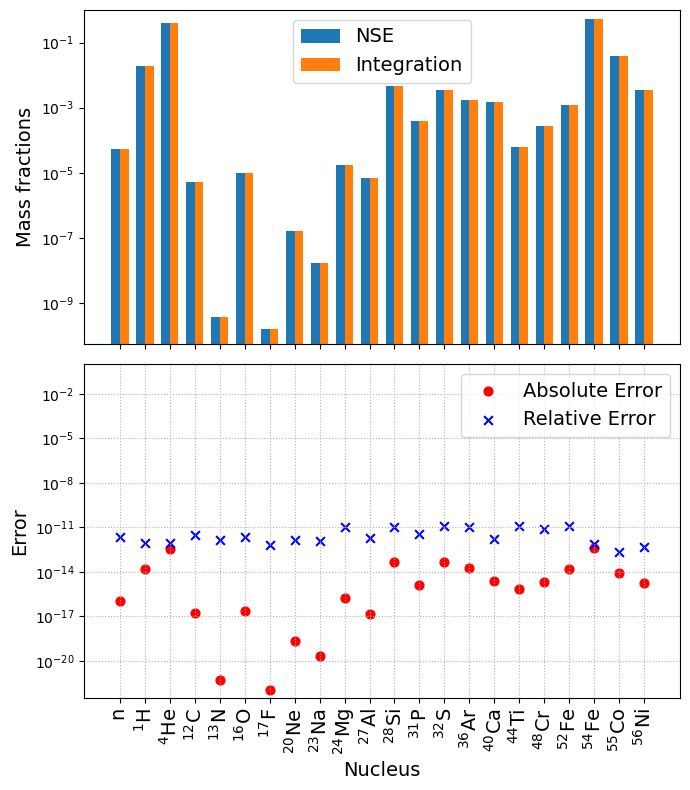

In [23]:
sol = net.integrate_network(tmax=1.e-1, rho=1e7, T=6e9, initial_comp="uniform", 
                            screen_method="potekhin_1998", rtol=3.e-14, atol=3.e-14)
fig = net.plot_evolution(sol, size=(700, 500))
NSE_comparison(net, sol)

The error plot above shows that NSE and integration agrees to machine-precision once again.